# Experimento 12 — Entrenar sin las reseñas de etiqueta casi aleatoria

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento11.ipynb` (detector de opinión + TF-IDF por partes con stemming + selección de
3.000 features con chi² + LinearSVC). La sección 1 repite de forma resumida la configuración común (misma semilla,
mismo split y mismos folds). Los experimentos anteriores **no se vuelven a ejecutar**: sus métricas se registran como
valores fijos tomados de sus notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 12 — Entrenar sin las reseñas de etiqueta casi aleatoria

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de experimentos anteriores tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 4, "descripcion": "Detector de opinión + TF-IDF por partes, LinearSVC (C=0,2)",
     "acc_train": 0.9770, "acc_cv": 0.9009, "std_cv": 0.0057, "acc_test": 0.8975, "envio": "submission_04.csv",
     "kaggle_publico": None},
    {"experimento": 9, "descripcion": "Dos niveles (stacking) con corrección de tipeo, SVM RBF",
     "acc_train": 0.9358, "acc_cv": 0.9065, "std_cv": 0.0086, "acc_test": 0.9029, "envio": "submission_09.csv",
     "kaggle_publico": 0.91555},
    {"experimento": 10, "descripcion": "Exp. 4 + stemming, LinearSVC (C=0,2)",
     "acc_train": 0.9776, "acc_cv": 0.9027, "std_cv": 0.0074, "acc_test": 0.9000, "envio": "submission_10.csv",
     "kaggle_publico": None},
    {"experimento": 11, "descripcion": "Exp. 10 + chi² (k=3.000), LinearSVC (C=0,5)",
     "acc_train": 0.9337, "acc_cv": 0.9015, "std_cv": 0.0048, "acc_test": 0.8967, "envio": "submission_11.csv",
     "kaggle_publico": 0.89},
]:
    resultados.append(fila)

ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 4", "escenario": "Original", "accuracy": 0.8975},
    {"modelo": "Exp. 4", "escenario": "Oraciones desordenadas", "accuracy": 0.7358},
    {"modelo": "Exp. 4", "escenario": "Última oración al inicio", "accuracy": 0.5946},
    {"modelo": "Exp. 11", "escenario": "Original", "accuracy": 0.8967},
    {"modelo": "Exp. 11", "escenario": "Oraciones desordenadas", "accuracy": 0.7238},
    {"modelo": "Exp. 11", "escenario": "Última oración al inicio", "accuracy": 0.5721},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,4,"Detector de opinión + TF-IDF por partes, LinearSVC (C=0,2)",NaN,0.9770,0.9009,0.0057,NaN,0.8975,NaN,submission_04.csv,NaN
2,9,"Dos niveles (stacking) con corrección de tipeo, SVM RBF",NaN,0.9358,0.9065,0.0086,NaN,0.9029,NaN,submission_09.csv,0.91555
3,10,"Exp. 4 + stemming, LinearSVC (C=0,2)",NaN,0.9776,0.9027,0.0074,NaN,0.9000,NaN,submission_10.csv,NaN
4,11,"Exp. 10 + chi² (k=3.000), LinearSVC (C=0,5)",NaN,0.9337,0.9015,0.0048,NaN,0.8967,NaN,submission_11.csv,0.89000


## 2. Experimento 12 — Entrenar sin las reseñas de etiqueta casi aleatoria

**Motivación:** el experimento 11 redujo la brecha entre entrenamiento y validación de 7,5 a 3,2 puntos con
selección de features, sin perder accuracy. Queda la pregunta de **qué es esa brecha que resta**. En el experimento
4 se encontró que ≈ 16 % de las reseñas `negativo`/`positivo` (≈ 11 % de todas) terminan en una frase evasiva
(*"ni lo mejor ni lo peor"*, *"sigo con dudas"*...) y que su etiqueta es **prácticamente aleatoria**: ninguna parte
del texto la predice mejor que el azar. Un modelo no puede aprender nada de esas reseñas; solo puede **memorizarlas**,
y eso aparece como brecha.

**Idea:** no usar esas reseñas para **entrenar**. Es una técnica clásica para datos con etiquetas ruidosas. La
**evaluación** sigue haciéndose con todas las reseñas (incluidas las ruidosas), porque eval también las contiene.

**Hipótesis:** sin las reseñas ruidosas en el entrenamiento, la brecha baja de forma clara y la accuracy de
validación se mantiene.

**Además:** se comparan los dos clasificadores lineales del curso, **LinearSVC y regresión logística**, cada uno con
su propia grilla de `C`, y la CV elige.

**Proceso:**
1. Diagnóstico: cuánto de la brecha del experimento 11 viene de las reseñas ruidosas.
2. Definir las reseñas ruidosas y el estimador que las excluye al entrenar.
3. `GridSearchCV` con tres decisiones: excluir o no las reseñas ruidosas, clasificador (LinearSVC / regresión
   logística) y `C`.
4. Modelo final, test, features, robustez y envío.

### 2.1 Definiciones

Las mismas funciones y el transformador `PartesE5` de `experimento5.ipynb` (con sus parámetros por defecto es el
detector de opinión del experimento 4), y el TF-IDF con stemming y la selección chi² del experimento 11.

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


mascara_np = (y_train != "neutral").to_numpy()
y_np = y_train.to_numpy()
termina_evasiva = X_train.map(lambda t: es_evasiva(dividir_oraciones(t)[-1])).to_numpy()

In [7]:
from nltk.stem import SnowballStemmer
from sklearn.base import ClassifierMixin
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

STEMMER = SnowballStemmer("spanish")
PATRON_TOKEN = re.compile(r"(?u)\b\w\w+\b")      # el mismo patrón de palabras que usa TfidfVectorizer por defecto
_RAICES = {}


def raiz(palabra):
    if palabra not in _RAICES:
        _RAICES[palabra] = STEMMER.stem(palabra)
    return _RAICES[palabra]


def tokenizar_con_stemming(texto):
    return [raiz(p) for p in PATRON_TOKEN.findall(texto)]


def tfidf_partes(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True,
                           tokenizer=tokenizar_con_stemming, token_pattern=None)


COLUMNAS_PARTES = ["texto", "ultima_op", "tras_sin_ev"]


def pipeline_e11(clf, k=3000):
    """Modelo del experimento 11: partes -> TF-IDF con stemming -> chi² (k features) -> clasificador."""
    return Pipeline([
        ("partes", PartesE5()),
        ("tfidf", ColumnTransformer([(c, tfidf_partes(), c) for c in COLUMNAS_PARTES])),
        ("sel", SelectKBest(chi2, k=k)),
        ("clf", clf),
    ])

### 2.2 Diagnóstico: ¿de dónde viene la brecha del experimento 11?

Se define como **reseña ruidosa** una reseña `negativo`/`positivo` cuya **última oración es una frase evasiva**
(la lista de evasivas del experimento 4). Con el modelo del experimento 11 (LinearSVC, `C = 0,5`) se mide, en cada
uno de los 5 folds, la accuracy en las reseñas de entrenamiento y de validación, separando las ruidosas del resto.

In [8]:
def termina_en_evasiva(textos):
    return np.array([es_evasiva(dividir_oraciones(t)[-1]) for t in textos])


def es_ruidosa(textos, etiquetas):
    """Reseñas negativo/positivo que terminan en una frase evasiva (etiqueta prácticamente aleatoria)."""
    return (np.asarray(etiquetas) != "neutral") & termina_en_evasiva(textos)


ruidosa_train = es_ruidosa(X_train, y_train)
print(f"Reseñas ruidosas en X_train: {ruidosa_train.sum():,} de {len(X_train):,} ({ruidosa_train.mean():.1%})")

y_np = y_train.to_numpy()
filas = []
for idx_tr, idx_va in skf.split(X_train, y_train):
    m = pipeline_e11(LinearSVC(C=0.5, max_iter=5000, random_state=SEED)).fit(X_train.iloc[idx_tr], y_train.iloc[idx_tr])
    for parte, idx in [("entrenamiento", idx_tr), ("validación", idx_va)]:
        p = m.predict(X_train.iloc[idx])
        r = ruidosa_train[idx]
        filas.append({"parte": parte, "total": (p == y_np[idx]).mean(),
                      "reseñas ruidosas": (p[r] == y_np[idx][r]).mean(), "resto": (p[~r] == y_np[idx][~r]).mean()})
diag = pd.DataFrame(filas).groupby("parte").mean().loc[["entrenamiento", "validación"]]
diag.loc["brecha"] = diag.loc["entrenamiento"] - diag.loc["validación"]
diag.round(4)

Reseñas ruidosas en X_train: 1,078 de 9,600 (11.2%)


,total,reseñas ruidosas,resto
parte,,,
entrenamiento,0.9337,0.6269,0.9725
validación,0.9015,0.4847,0.9539
brecha,0.0322,0.1422,0.0186


**Lectura**

- **En las reseñas ruidosas el modelo memoriza:** acierta el 62,7 % de ellas en entrenamiento, pero en
  validación solo el 48,5 %, que es azar. La brecha en ese grupo es de **14 puntos**.
- **En el resto, la brecha es de solo 1,9 puntos** (0,973 frente a 0,954): ahí el modelo generaliza bien.
- Aunque las reseñas ruidosas son solo el 11,2 % de los datos, aportan **≈ 1,6 de los 3,2 puntos** de brecha del
  experimento 11 (0,112 × 14,2): **la mitad del sobreajuste que queda es memorización de etiquetas aleatorias**.
- Esa memorización no le sirve al modelo para nada en datos nuevos (en validación acierta el 48,5 %): solo consume
  capacidad del modelo y desplaza los pesos de las features hacia patrones que no se repiten.

### 2.3 Estimador que excluye las reseñas ruidosas al entrenar

`SinRuidosas` envuelve el pipeline del experimento 11. En `fit` identifica las reseñas ruidosas **del conjunto de
entrenamiento que recibe** y entrena el pipeline sin ellas; en `predict` usa el pipeline tal cual, solo con el texto.

**¿Es leakage?** Para identificar una reseña ruidosa hace falta su etiqueta (`negativo`/`positivo`), así que el filtro
**solo puede aplicarse a datos de entrenamiento**. Al ir dentro del estimador, en cada fold de la CV se aplica
únicamente a las reseñas de entrenamiento de ese fold; las de validación (y las de test y eval) se predicen todas,
sin filtrar. Es el mismo principio de todo lo que aprende de los datos: va dentro de `fit`.

El parámetro `excluir_ruidosas` permite que la CV compare el mismo modelo con y sin el filtro.

In [9]:
class SinRuidosas(BaseEstimator, ClassifierMixin):
    """Pipeline del experimento 11 entrenado sin las reseñas de etiqueta casi aleatoria."""

    def __init__(self, clf=None, excluir_ruidosas=True, k=3000):
        self.clf = clf
        self.excluir_ruidosas = excluir_ruidosas
        self.k = k

    def fit(self, X, y):
        X = list(X)
        y = np.asarray(y)
        usar = ~es_ruidosa(X, y) if self.excluir_ruidosas else np.ones(len(y), dtype=bool)
        self.n_excluidas_ = int((~usar).sum())
        self.modelo_ = pipeline_e11(clone(self.clf), self.k).fit([x for x, u in zip(X, usar) if u], y[usar])
        self.classes_ = self.modelo_.classes_
        return self

    def predict(self, X):
        return self.modelo_.predict(list(X))


ejemplo = SinRuidosas(LinearSVC(C=0.5, max_iter=5000, random_state=SEED)).fit(X_train, y_train)
print(f"Reseñas excluidas del entrenamiento: {ejemplo.n_excluidas_:,} de {len(X_train):,}")

Reseñas excluidas del entrenamiento: 1,078 de 9,600


### 2.4 Búsqueda: filtro × clasificador × `C`

Un único `GridSearchCV` evalúa todas las combinaciones de:
- **`excluir_ruidosas`**: sí / no (con "no" es exactamente el modelo del experimento 11);
- **clasificador**: LinearSVC con `C` ∈ {0,2, 0,5, 1} o regresión logística con `C` ∈ {1, 3, 10} (cada uno con su
  propia grilla);
- las 3.000 features de chi² se mantienen fijas (el experimento 11 mostró que con más features solo aumenta la brecha).

Como las diferencias esperadas son pequeñas, se usa **CV repetida: 3 repeticiones × 5 folds = 15 particiones**, las
mismas para todas las combinaciones; así la comparación tiene menos ruido que con 5 folds. Se registra también la
accuracy de **entrenamiento** de cada combinación (calculada sobre **todas** las reseñas de entrenamiento del fold,
incluidas las ruidosas) para medir la brecha. Esta celda tarda ≈ 10 minutos.

In [10]:
cv_repetida = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

grid_e12 = [
    {"excluir_ruidosas": [False, True],
     "clf": [LinearSVC(max_iter=5000, random_state=SEED)], "clf__C": [0.2, 0.5, 1]},
    {"excluir_ruidosas": [False, True],
     "clf": [LogisticRegression(max_iter=3000, random_state=SEED)], "clf__C": [1, 3, 10]},
]
busqueda_e12 = GridSearchCV(SinRuidosas(), grid_e12, cv=cv_repetida, scoring=SCORING, refit="accuracy",
                            return_train_score=True, n_jobs=-1)
busqueda_e12.fit(X_train, y_train)

tabla_e12 = tabla_cv(busqueda_e12)
params = tabla_e12.pop("params")
tabla_e12.insert(0, "clasificador", params.map(lambda p: type(p["clf"]).__name__))
tabla_e12.insert(1, "C", params.map(lambda p: p["clf__C"]))
tabla_e12.insert(2, "sin ruidosas", params.map(lambda p: p["excluir_ruidosas"]))
tabla_e12["brecha"] = tabla_e12["acc_train"] - tabla_e12["acc_cv"]
mejor = busqueda_e12.best_params_
print(f"Mejor combinación: {type(mejor['clf']).__name__}, C = {mejor['clf__C']}, "
      f"sin ruidosas = {mejor['excluir_ruidosas']} | CV = {busqueda_e12.best_score_:.4f}")
tabla_e12.round(4)

Mejor combinación: LinearSVC, C = 0.5, sin ruidosas = True | CV = 0.9033


,clasificador,C,sin ruidosas,acc_train,acc_cv,std_cv,f1_cv,seg_ajuste,brecha
3,LinearSVC,0.5,True,0.9188,0.9033,0.0070,0.9076,12.2059,0.0155
5,LinearSVC,1.0,True,0.9236,0.9029,0.0069,0.9073,12.5236,0.0207
2,LinearSVC,0.5,False,0.9336,0.9027,0.0062,0.9071,13.6282,0.0309
1,LinearSVC,0.2,True,0.9135,0.9027,0.0070,0.9068,11.9860,0.0108
4,LinearSVC,1.0,False,0.9427,0.9022,0.0070,0.9067,14.4386,0.0405
0,LinearSVC,0.2,False,0.9232,0.9021,0.0070,0.9064,13.5034,0.0211
9,LogisticRegression,3.0,True,0.9198,0.9014,0.0077,0.9057,12.4732,0.0184
7,LogisticRegression,1.0,True,0.9126,0.9007,0.0073,0.9048,12.2726,0.0119
11,LogisticRegression,10.0,True,0.9284,0.9006,0.0079,0.9051,11.7513,0.0278
8,LogisticRegression,3.0,False,0.9379,0.9001,0.0060,0.9046,13.7812,0.0378


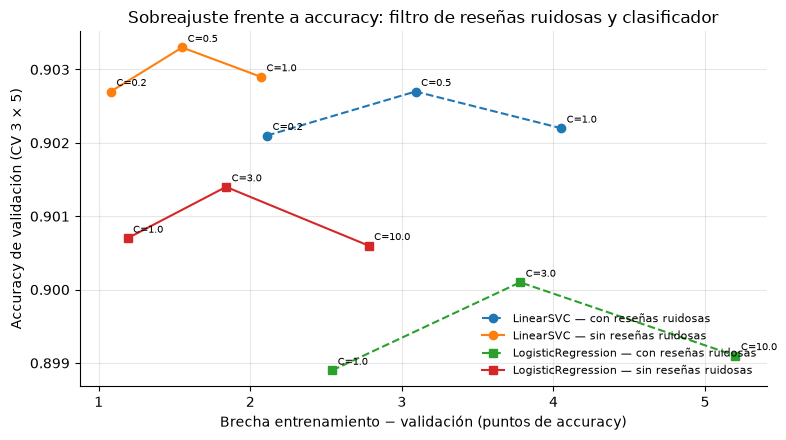

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for (clasificador, sin_ruido), d in tabla_e12.groupby(["clasificador", "sin ruidosas"]):
    d = d.sort_values("C")
    ax.plot(100 * d["brecha"], d["acc_cv"], marker="o" if clasificador == "LinearSVC" else "s",
            linestyle="-" if sin_ruido else "--",
            label=f"{clasificador} — {'sin' if sin_ruido else 'con'} reseñas ruidosas")
    for _, f in d.iterrows():
        ax.annotate(f"C={f['C']}", (100 * f["brecha"], f["acc_cv"]), textcoords="offset points", xytext=(4, 4), fontsize=7)
ax.set_xlabel("Brecha entrenamiento − validación (puntos de accuracy)")
ax.set_ylabel("Accuracy de validación (CV 3 × 5)")
ax.set_title("Sobreajuste frente a accuracy: filtro de reseñas ruidosas y clasificador")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

**Lectura**

- **Excluir las reseñas ruidosas mejora todas las combinaciones.** En las 6 combinaciones de clasificador y `C`,
  la versión sin ruidosas tiene **mayor** accuracy de CV (entre +0,06 y +0,18 puntos) y **menor** brecha. Cada
  diferencia individual es pequeña frente a la desviación entre particiones, pero que se repita en las 6 indica un
  efecto real: el modelo no pierde nada al dejar de ver esas reseñas, y gana un poco porque deja de aprender ruido.
- **La brecha baja a la mitad o menos:** con LinearSVC `C = 0,5`, de 3,1 a **1,5** puntos; con regresión logística
  `C = 3`, de 3,8 a 1,8; con `C` más bajos llega a 1,1–1,2 puntos.
- **LinearSVC frente a regresión logística:** con las mismas features y el mismo filtro, LinearSVC queda ≈ 0,2 puntos
  por encima (0,9033 frente a 0,9014), como en los experimentos 4, 10 y 11. La diferencia es pequeña y la regresión
  logística sería una alternativa válida; la CV elige **LinearSVC con `C = 0,5` sin reseñas ruidosas**.
- En el gráfico, las curvas "sin reseñas ruidosas" (líneas continuas) quedan **arriba y a la izquierda** de las
  curvas "con" (discontinuas): más accuracy con menos sobreajuste, para ambos clasificadores.

### 2.5 Evaluación en test

Test -> accuracy: 0.8958 | F1 macro: 0.9005

              precision    recall  f1-score   support

    negativo      0.859     0.847     0.853       843
     neutral      0.986     0.999     0.992       715
    positivo      0.854     0.857     0.856       842

    accuracy                          0.896      2400
   macro avg      0.900     0.901     0.900      2400
weighted avg      0.895     0.896     0.896      2400



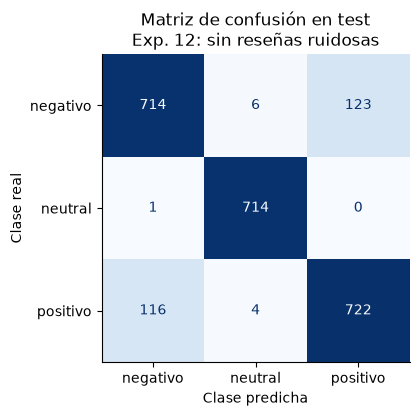

Negativo vs positivo en test: 0.852
  reseñas ruidosas (285): 0.456
  resto (2115): 0.955


In [12]:
modelo_e12 = busqueda_e12.best_estimator_
metricas_e12 = evaluar_en_test(modelo_e12, "Exp. 12: sin reseñas ruidosas")
np_test = (y_test != "neutral").to_numpy()
ruidosa_test = es_ruidosa(X_test, y_test)
pred = metricas_e12["pred"]
y_t = y_test.to_numpy()
print(f"Negativo vs positivo en test: {(pred[np_test] == y_t[np_test]).mean():.3f}")
print(f"  reseñas ruidosas ({ruidosa_test.sum()}): {(pred[ruidosa_test] == y_t[ruidosa_test]).mean():.3f}")
print(f"  resto ({(~ruidosa_test).sum()}): {(pred[~ruidosa_test] == y_t[~ruidosa_test]).mean():.3f}")

### 2.6 Features y coeficientes del modelo final

In [13]:
final = modelo_e12.modelo_
nombres = final.named_steps["tfidf"].get_feature_names_out()[final.named_steps["sel"].get_support()]
clf = final.named_steps["clf"]
print(f"Features seleccionadas: {len(nombres):,} | reseñas excluidas del entrenamiento: {modelo_e12.n_excluidas_:,}")
pd.DataFrame({clase: [f"{nombres[j]} ({clf.coef_[c][j]:.2f})" for j in clf.coef_[c].argsort()[::-1][:12]]
              for c, clase in enumerate(clf.classes_)})[CLASES]

Features seleccionadas: 3,000 | reseñas excluidas del entrenamiento: 1,078


,negativo,neutral,positivo
0,tras_sin_ev__corrient (2.68),texto__kil (0.80),ultima_op__confiabl (1.96)
1,ultima_op__poc fiabl (2.39),texto__usb (0.76),ultima_op__decent (1.96)
2,tras_sin_ev__poc fiabl (2.29),texto__magnet (0.76),ultima_op__rapidisim (1.94)
3,ultima_op__incumplidor (2.23),texto__el paquet (0.73),ultima_op__buenisim (1.94)
4,ultima_op__inconsistent (2.12),texto__tra (0.73),tras_sin_ev__comodisim (1.94)
5,ultima_op__ordinari (2.07),texto__pedi por (0.72),tras_sin_ev__formid (1.93)
6,tras_sin_ev__pobr (2.06),ultima_op__guard (0.71),tras_sin_ev__resistent (1.93)
7,ultima_op__fragil (2.02),texto__vien (0.70),ultima_op__correct (1.89)
8,ultima_op__chapucer (2.01),texto__unidad (0.70),ultima_op__redond (1.89)
9,ultima_op__mal (2.00),ultima_op__ver (0.70),tras_sin_ev__correct (1.86)


### 2.7 Prueba de robustez en test

In [14]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 12", "escenario": e, "accuracy": accuracy_score(y_test, modelo_e12.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 11,Exp. 12,Exp. 4
escenario,,,
Original,0.8967,0.8958,0.8975
Oraciones desordenadas,0.7238,0.7317,0.7358
Última oración al inicio,0.5721,0.5725,0.5946


### 2.8 Registro y envío

In [15]:
i = busqueda_e12.best_index_
resultados.append({
    "experimento": 12,
    "descripcion": f"Exp. 11 sin reseñas ruidosas al entrenar, {type(mejor['clf']).__name__} (C={mejor['clf__C']})",
    "acc_train": round(busqueda_e12.cv_results_["mean_train_accuracy"][i], 4),
    "acc_cv": round(busqueda_e12.cv_results_["mean_test_accuracy"][i], 4),
    "std_cv": round(busqueda_e12.cv_results_["std_test_accuracy"][i], 4),
    "acc_test": round(metricas_e12["acc_test"], 4),
    "envio": "submission_12.csv",
    "kaggle_publico": None,
})
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,4,"Detector de opinión + TF-IDF por partes, LinearSVC (C=0,2)",NaN,0.9770,0.9009,0.0057,NaN,0.8975,NaN,submission_04.csv,NaN
2,9,"Dos niveles (stacking) con corrección de tipeo, SVM RBF",NaN,0.9358,0.9065,0.0086,NaN,0.9029,NaN,submission_09.csv,0.91555
3,10,"Exp. 4 + stemming, LinearSVC (C=0,2)",NaN,0.9776,0.9027,0.0074,NaN,0.9000,NaN,submission_10.csv,NaN
4,11,"Exp. 10 + chi² (k=3.000), LinearSVC (C=0,5)",NaN,0.9337,0.9015,0.0048,NaN,0.8967,NaN,submission_11.csv,0.89000
5,12,"Exp. 11 sin reseñas ruidosas al entrenar, LinearSVC (C=0.5)",NaN,0.9188,0.9033,0.0070,NaN,0.8958,NaN,submission_12.csv,NaN


In [16]:
envio_e12 = generar_envio(busqueda_e12, numero=12)

Envío guardado en envios/submission_12.csv y modelo en modelos/modelo_12.joblib
Distribución de predicciones en eval (%):
answer
negativo    35.1
neutral     28.0
positivo    36.9


### 2.9 Análisis del experimento 12

**Resultados:** accuracy de CV (3 × 5) = **0,9033 ± 0,0070** (LinearSVC, `C = 0,5`, entrenado sin las 1.078
reseñas ruidosas) y accuracy en test = **0,8958**.

| | Exp. 4 | Exp. 10 | Exp. 11 | **Exp. 12** |
|---|---|---|---|---|
| Cambio | — | stemming | + chi² (3.000) | + sin reseñas ruidosas al entrenar |
| Features | 42.177 | 37.360 | 3.000 | 3.000 |
| Accuracy de entrenamiento | 0,977 | 0,978 | 0,934 | **0,919** |
| Accuracy CV | 0,901 | 0,903 | 0,902 (0,9027 con 3 × 5) | **0,9033** (3 × 5) |
| **Brecha entrenamiento − CV** | 7,6 | 7,5 | 3,1 | **1,5** |
| Accuracy test | 0,898 | 0,900 | 0,897 | 0,896 |
| Test, oraciones desordenadas | 0,736 | 0,736 | 0,724 | 0,732 |

1. **La hipótesis se confirma.** Sin las reseñas ruidosas en el entrenamiento, la brecha baja de 3,1 a **1,5 puntos**
   y la accuracy de validación se mantiene (sube 0,06). La accuracy de entrenamiento (0,919) ya es muy parecida a la
   de validación: el modelo **casi no sobreajusta**.
2. **Recorrido del sobreajuste:** 7,6 puntos (exp. 4) → 3,1 (exp. 11, quitando features que solo servían para
   memorizar) → 1,5 (exp. 12, quitando ejemplos cuya etiqueta solo se puede memorizar). La accuracy de validación se
   mantuvo en ≈ 0,90 en todo el recorrido: el sobreajuste que se eliminó **no aportaba nada** en datos nuevos.
3. **En test** queda en 0,896, dentro del error estándar (≈ 0,006) de los experimentos 4, 10 y 11. En las 285
   reseñas ruidosas del test acierta el 45,6 % y en el resto el **95,5 %**: lo predecible lo predice igual de bien
   que los modelos anteriores.
4. **La robustez no cambia** respecto al experimento 11: sigue dependiendo de que el veredicto esté al final.
5. **Por qué es el modelo que mejor generaliza:** tiene la misma accuracy que todos los buenos modelos de un nivel,
   pero con la menor brecha, 3.000 features y sin depender de patrones débiles en reseñas impredecibles (como el
   stacking de los experimentos 6 a 9). Su rendimiento en entrenamiento es una buena estimación de su rendimiento en
   datos nuevos.

**Límites:**
- El filtro usa la lista de frases evasivas construida en el experimento 4 con el análisis de errores de `X_train`.
  Es una regla del dominio, no aprendida; reseñas ruidosas con otras formas de evasiva siguen en el entrenamiento.
- En eval también hay ≈ 11 % de reseñas de este tipo; el modelo las predice con ≈ 50 % de acierto, como cualquier
  otro. Excluirlas del entrenamiento no cambia ese techo.
- La regresión logística, con el mismo filtro, queda 0,2 puntos por debajo con una brecha similar: si se prefiere
  por interpretabilidad (probabilidades), es una alternativa equivalente.

**Decisión:** el experimento 12 es el **modelo de un nivel que mejor generaliza**: LinearSVC (`C = 0,5`) sobre 3.000
features de chi², entrenado sin las reseñas de etiqueta casi aleatoria. Se genera `submission_12.csv`.